In [68]:
import casadi as ca
from environments.utils.funcionesEMS import*
from environments.utils.funcionesEMS import manage_batteries as manage_batteries2
from environments.Data.EMS.EMS_constants import *
import matplotlib.pyplot as plt
from scipy.special import exp1
import numpy as np
from environments.EMS_policies import PumpingPolicy
from environments.EnergyWaterMG import EnergyWaterMG
import torch
from environments.utils.predict_utils import Predictor, load_model
from scipy.interpolate import interp1d

In [51]:
energy_water_mg = EnergyWaterMG()
pv_model = load_model("predictive_models/pv_model.pt", device="cuda")

pd_model = load_model("predictive_models/pd_model.pt", device="cuda")

c:\Users\CASI 5\Documents\RL_EMS\environments\utils\predict_utils.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean, dtype=torch.float32).to(device)
c:\Users\CASI 5\Documents\RL_EMS\environments\utils\predict_utils.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std, dtype=torch.float32).to(device)


pv_model


In [ ]:
obs = energy_water_mg.start()
horizon = 143
for i in range(horizon):
    pass

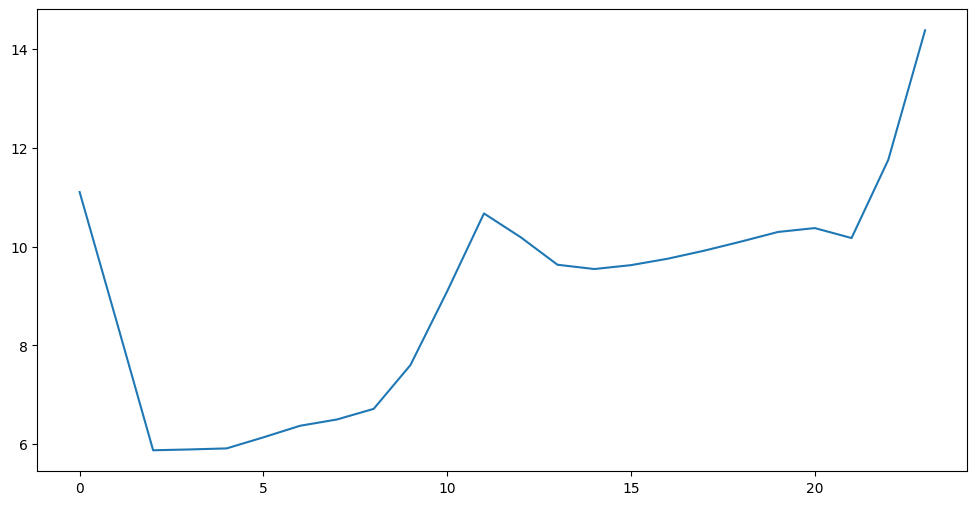

In [63]:
class Forecaster():
    def __init__(self, model:Predictor):
        self.model = model
        model.to("cpu")
        self.mean = model.mean.clone()
        self.std = model.std.clone()

    def predict(self, pv_array:np.ndarray, n_steps:int):
        pv_tensor = torch.tensor(pv_array, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
        with torch.no_grad():
            pv_tensor = (pv_tensor - self.mean) / self.std
            prediction = self.model.forward(pv_tensor, None, n_steps)
            prediction = torch.clamp_min(prediction * self.std + self.mean, 0.0)
        return prediction.detach().numpy().flatten()[-n_steps:]
    

        
pv_forecaster = Forecaster(pv_model)
prediction = pv_forecaster.predict(p_pv[0:144], 144)
pd_forecaster = Forecaster(pd_model)
prediction_pd = pd_forecaster.predict(p_d[0:48], 24)
plt.figure(figsize=(12, 6))
plt.plot(prediction_pd, label="Predicted Demand")

In [3]:
def drawdown(k: int, dQ: Iterable):  # drawdown of the well
    """
    Computes the drawdown of the well according the theis equation
    :param k: time instant
    :param dQ: delta flow rate [m3/s]
    :return: drawdown
    """
    assert k == len(dQ), "The length of dQ should match the number of temporal k points"
    
    l = np.arange(1, k + 1)
    arg = (r_wells ** 2 * S) / (4 * T * (k - l + 1) * 600)
    sum_ = 0.0
    for i in range(k):
        sum_ += dQ[i] * exp1(arg[i])
    s_val = 1 / (4 * np.pi * T) * sum_
    return s_val

In [4]:
def manage_batteries(SoE: ca.SX,
                     P_fv: ca.SX,
                     P_demanded: ca.SX,
                     P_pump: ca.SX) -> tuple[ca.SX, ca.SX]:
    """
    Choose the power to re/discharge the batteries and computes the next SoE
    :param SoE: State of Energy of the battery [kWh]
    :param P_fv: power generated by the PV panels [kW]
    :param P_demanded: power demanded by the loads [kW]
    :param P_pumps: list with the power demanded by the pumps
    :returns: Pbat, next_SoE, E_residual
    """
    E_surplus = ca.SX(0.0)
    E_deficit = ca.SX(0.0)

    P_residual = P_fv - P_demanded - P_pump
    Pbat = ca.if_else(ca.fabs(P_residual) > Pbat_max, ca.fmin(ca.fmax(P_residual, -Pbat_max), Pbat_max), P_residual)
    P_not_used = P_residual - Pbat

    delta_SoE = ca.if_else(Pbat >= 0, Pbat * n_c * (dt / 3600), Pbat / n_d * (dt / 3600))
    next_SoE = SoE + delta_SoE

    E_surplus = ca.if_else(next_SoE > SoE_max, next_SoE - SoE_max, 0)
    E_deficit = ca.if_else(next_SoE < SoE_min, SoE_min - next_SoE, 0)

    next_SoE = ca.fmin(ca.fmax(next_SoE, SoE_min), SoE_max)
    #Pbat = ca.if_else(delta_SoE > 0, ca.fmax(SoE_max - SoE, 0) / (dt / 3600) / n_c, ca.fmin(SoE_min - SoE, 0) * n_d / (dt / 3600))
    Pbat = ca.if_else(next_SoE > SoE_max , ca.fmax(SoE_max - SoE, 0) / (dt / 3600) / n_c, Pbat)
    Pbat = ca.if_else(next_SoE < SoE_min , ca.fmin(SoE_min - SoE, 0) * n_d / (dt / 3600), Pbat)

    E_surplus += ca.if_else(P_not_used > 0, P_not_used * (dt / 3600), 0)
    E_deficit += ca.if_else(P_not_used < 0, -P_not_used / n_d * (dt / 3600), 0)

    E_residual = E_surplus + E_deficit

    return Pbat, E_residual


In [69]:

class MPCPumping():
    def __init__(self, pv_model:Forecaster, pd_model:Forecaster):
        self.prev_Q = 0.0  # Previous flow rate
        self.pv_model = pv_model
        self.domestic_model =pd_model
        self.ten_min_counter:int = 0

        self.pv:list = None
        self.pd:list = None

        self.pd_predictions:np.ndarray = None

    def init_buffer(self, pv:np.ndarray, pd:np.ndarray):
        """
        Initialize the buffer with the historical data of the PV and PD
        """
        self.pv = pv.tolist()
        self.pd = pd.tolist()
        self.ten_min_counter = 0
        


    def get_predictions(self, obs:np.ndarray, p_pv:float, p_d:float, N:int):
        # Define the control horizon

        #update the buffer
        if self.pv is None or self.pd is None:
            raise ValueError("Buffer not initialized. Call init_buffer() with historical data.")
        
        self.pv.append(p_pv)
        self.pv.pop(0)
        
        if self.ten_min_counter % 6 == 0:  # Every 10 minutes
            self.pd.append(p_d)
            self.pd.pop(0)
            # now compute the predictions
            self.pd_predictions = self.domestic_model.predict(np.array(self.pd), N//6)
            # Interpolate pd_predictions to 6x higher resolution
            x_old = np.arange(len(self.pd_predictions))
            x_new = np.linspace(0, len(self.pd_predictions) - 1, len(self.pd_predictions) * 6)
            interp_func = interp1d(x_old, self.pd_predictions, kind='linear')
            self.pd_predictions = interp_func(x_new)
        self.ten_min_counter += 1
        
        p_pv_predicted = self.pv_model.predict(np.array(self.pv), N)
        return p_pv_predicted, self.pd_predictions[-N:]

        

In [82]:
radiation = get_rad()
temperature = get_temperatura()
p_pv = solar_power(radiation, temperature)
demand = get_demand_2()
mpc_pumping = MPCPumping(pv_forecaster, pd_forecaster)

mpc_pumping.init_buffer(p_pv[0:144], demand[:48])
folder = "pv_animation"
import os
if not os.path.exists(folder):
    os.makedirs(folder)


for i in range(143):
    fig, ax = plt.subplots(figsize=(10, 4))
    pred1, _ = mpc_pumping.get_predictions([], p_pv[144+i], demand[i//6], 143-i)
    t_data = np.linspace(0, (144 + i)/6, 144 + i)
    t_preds = np.linspace((144 + i +1)/6, 288/6, 143-i)

    ax.plot(t_data, p_pv[:144+i], label="PV Power", color='blue')
    ax.plot(t_preds, p_pv[144+i+1:288], label="PV Power", color='blue', alpha=0.5)
    ax.plot(t_preds, pred1, label="Predicted PV Power", color='orange', ls  = '--')
    ax.legend()
    fig.savefig("pv_animation/pv_power_{}.png".format(i), dpi=300)
    plt.close(fig)
    

C:\Users\CASI 5\AppData\Roaming\Python\Python313\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


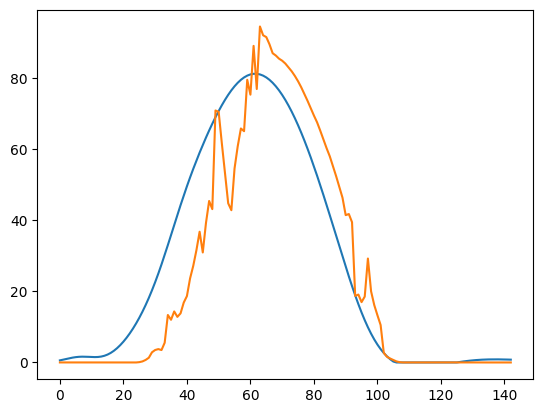

In [73]:
plt.plot(pred1, label="Predicted PV")
plt.plot(p_pv[144:287], label="Demand")
#plt.plot(pred2, label="Predicted Demand")

In [ ]:
# Define optimization variables
U = ca.SX.sym("U", 2, N)  # Control inputs
X = ca.SX.sym("X", 5, N + 1)  # States
K_p = 1.0
# Define the cost function and constraints
cost = 0

v_tank, v_irr, drawdown, soe = obs[0], obs[1], obs[2], obs[4]


# Initial conditions
constraints = [(X[0,0] - v_tank),  # v_tanks
            (X[1,0] - v_irr),   # v_irrs
            (X[2,0] - drawdown),  # drawdown
            (X[3,0]- soe), # soe
            (X[4,0] - self.prev_Q)] # Previous qp
            

for k in range(N):
    # Dynamics constraint
    constraints.append(X[0,k + 1] - (X[0, k] + (U[0, k]-U[1, k])*dt/1000))  # Vtanks
    constraints.append(X[1,k + 1] - (X[1, k] + U[1, k]*dt/1000))  # Virrs

    constraints.append(X[2,k + 1] - (1-0.0233)*X[2,k] - 0.1418*U[0,k] + 0.1036*X[4,k]) # Drawdown
    p_bat, e_res = manage_batteries(X[2, k], float(p_pv[k]), float(p_d[k]), K_p*U[0, k])
    constraints.append(X[3,k + 1] - (X[2, k] + p_bat*dt/3600))  # SoE
    constraints.append(X[4,k + 1] - U[0,k])  # Previous qp
    
    # Update 

    constraints.append(X[0,k+1])
    constraints.append(X[1,k+1])
    constraints.append(X[2,k+1])
    constraints.append(X[3,k+1])
    #constraints.append(X[4,k+1])

    constraints.append(U[0,k])
    constraints.append(U[1,k])
    cost += -e_res

# Define bounds for constraints
lbg = [0,0,0,0]  # Equality constraint for initial condition
ubg = [0,0,0,0]

for k in range(N):
    # Equality constraints for dynamics
    lbg.extend([0, 0, 0, 0])  # Lower bounds for dynamics
    ubg.extend([0, 0, 0, 0])  # Upper bounds for dynamics

    lbg.extend([1, 0, 20, 0])  # Lower bounds 
    ubg.extend([5, ca.inf, 100, 1])  # Upper bounds 

    # Inequality constraint for U[0, k] >= 0
    lbg.extend([0, 0])  # Lower bound
    ubg.extend([1.0, 1.0])  # No upper bound

# Final condition (equality constraint)
lbg.append(0)
ubg.append(0)

constraints.append(X[1, N] - 5)  # Final condition (reference fulfillment)

# Combine decision variables into a single vector
decision_variables = ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1))
# Create the NLP problem
nlp_control = {
    'x': ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1)),
    'f': cost,             # Objective function
    'g': ca.vertcat(*constraints)  # Constraints
}

# Create the solver
solver_control = ca.nlpsol('solver_control', 'ipopt', nlp_control)
#

solution_control = solver_control(
    x0=np.zeros((4 * (N + 1) + 2 * N,)),  # Initial guess
    lbg=lbg,  # Lower bound on constraints
    ubg=ubg   # Upper bound on constraints
)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    12015
Number of nonzeros in inequality constraint Jacobian.:      858
Number of nonzeros in Lagrangian Hessian.............:      429

Total number of variables............................:      862
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      577
Total number of inequality constraints...............:      858
        inequality constraints with only lower bounds:      143
   inequality constraints with lower and upper bounds:      715
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.0194795e+03 5.00e+01 5.87e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [18]:
# Extract the solution for decision variables
solution_values = solution_control['x']

# Extract the cost value
solution_cost = solution_control['f']

# Extract the constraint values
solution_constraints = solution_control['g']

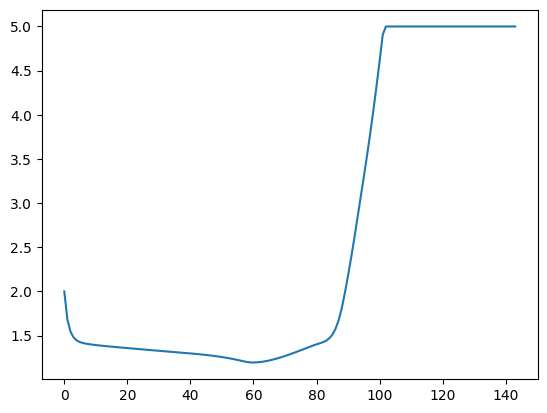

In [19]:
states = np.array(ca.reshape(solution_values[:4 * (N + 1)], (4, N + 1)))

plt.plot(states[0], label="x1")


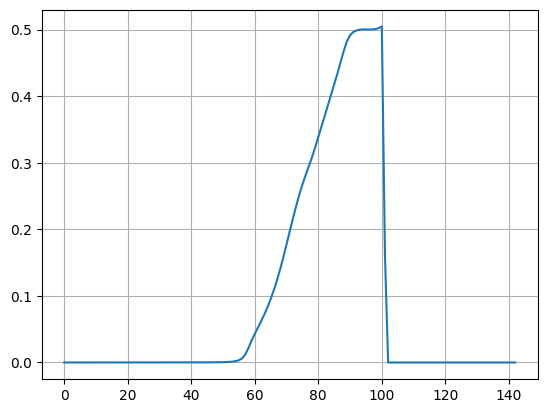

In [20]:
actions = np.array(ca.reshape(solution_values[4 * (N + 1):], (2, N)))
plt.plot(actions[0], label="u1")
plt.grid()

In [14]:
dQS = np.array([1 if k == 0 else -1 if k==1 else 0 for k in range(N)])
dQS = np.concatenate(([actions[0,0]], np.diff(actions[0])))
drawdown_values = [drawdown(k+1, dQS[:k+1]*1e-3) for k in range(N)]

NameError: name 'actions' is not defined

NameError: name 'drawdown_values' is not defined

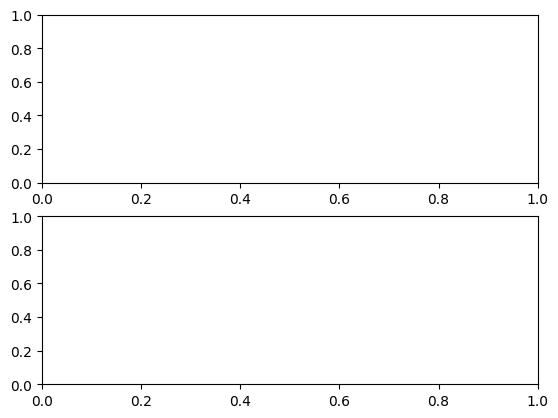

In [15]:
fig, ax = plt.subplots(2,1)
ax[0].plot(drawdown_values, label="drawdown")
ax[1].plot(actions[0])


In [10]:
pbats = []
e_res = []
for i in range(len(states[2])-1):
    pbat, _, e_res_ = manage_batteries2(states[2,i], float(p_pv[i]), float(p_d[i]), [K_p*actions[0, i]])
    pbats.append(float(pbat))
    e_res.append(float(e_res_))


NameError: name 'states' is not defined

In [13]:
len(actions[0])

287

In [9]:
plt.plot(pbats)

NameError: name 'pbats' is not defined

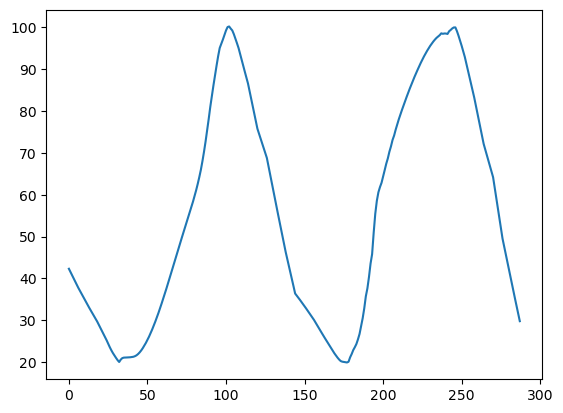

In [25]:
plt.plot(states[2], label="SoE")

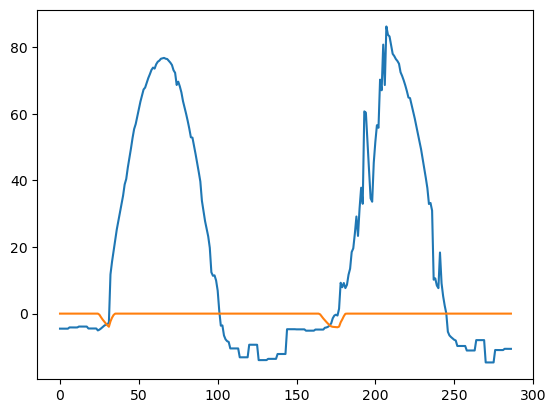

In [36]:
plt.plot(pbats)
plt.plot(e_res)

In [37]:
pbats

[-4.5146904522733395,
 -4.5167844392837955,
 -4.514311563765601,
 -4.51697715485194,
 -4.520310267948673,
 -4.519982418508062,
 -4.146254608781122,
 -4.152445552535308,
 -4.151688738871952,
 -4.146774623060076,
 -4.158546166026441,
 -4.141152316551536,
 -3.884788605567344,
 -3.8863832873116206,
 -3.8884896258273343,
 -3.8899713373927205,
 -3.885513243252005,
 -3.893434053942316,
 -4.46733017287533,
 -4.468866914432749,
 -4.469173371466576,
 -4.469601707805894,
 -4.468738576262369,
 -4.4679384917045155,
 -5.047610296292464,
 -4.813515776526771,
 -4.460296149736614,
 -4.034946846232396,
 -3.6375424633081326,
 -3.3390628320670634,
 -3.225748993495257,
 -2.6774876247580788,
 11.763936356447765,
 15.624798697074892,
 18.813017694520127,
 21.9826844240713,
 25.2686601046917,
 27.829924798525568,
 30.236132528353263,
 33.1105570551525,
 35.425527404970694,
 38.788936628412564,
 40.44771838003249,
 43.866088334326534,
 46.72241436227952,
 49.599907277934044,
 52.72505741688184,
 55.42676129559